Fig2DE


Step 1: Building training matrix (reading all slices)...
Calculating mean trajectories...
Building regression matrix...
Step 2: Training dPCA model...

[Time Component Analysis]
  > Subspace Total Energy relative to Global: 0.94%
  PC1: Global= 4.57% | Within Time Subspace=65.45%
  PC2: Global= 3.18% | Within Time Subspace=27.80%
  PC3: Global= 3.27% | Within Time Subspace= 4.20%
  PC4: Global= 2.24% | Within Time Subspace= 1.37%
  PC5: Global= 3.15% | Within Time Subspace= 0.60%

[Position Component Analysis]
  > Subspace Total Energy relative to Global: 5.24%
  PC1: Global= 9.92% | Within Position Subspace=55.40%
  PC2: Global= 5.14% | Within Position Subspace=20.08%
  PC3: Global= 2.32% | Within Position Subspace= 9.51%
  PC4: Global= 3.81% | Within Position Subspace= 5.50%
  PC5: Global= 1.83% | Within Position Subspace= 3.89%

[Stimulus Component Analysis]
  > Subspace Total Energy relative to Global: 0.88%
  PC1: Global= 4.65% | Within Stimulus Subspace=58.20%
  PC2: Global= 3.37

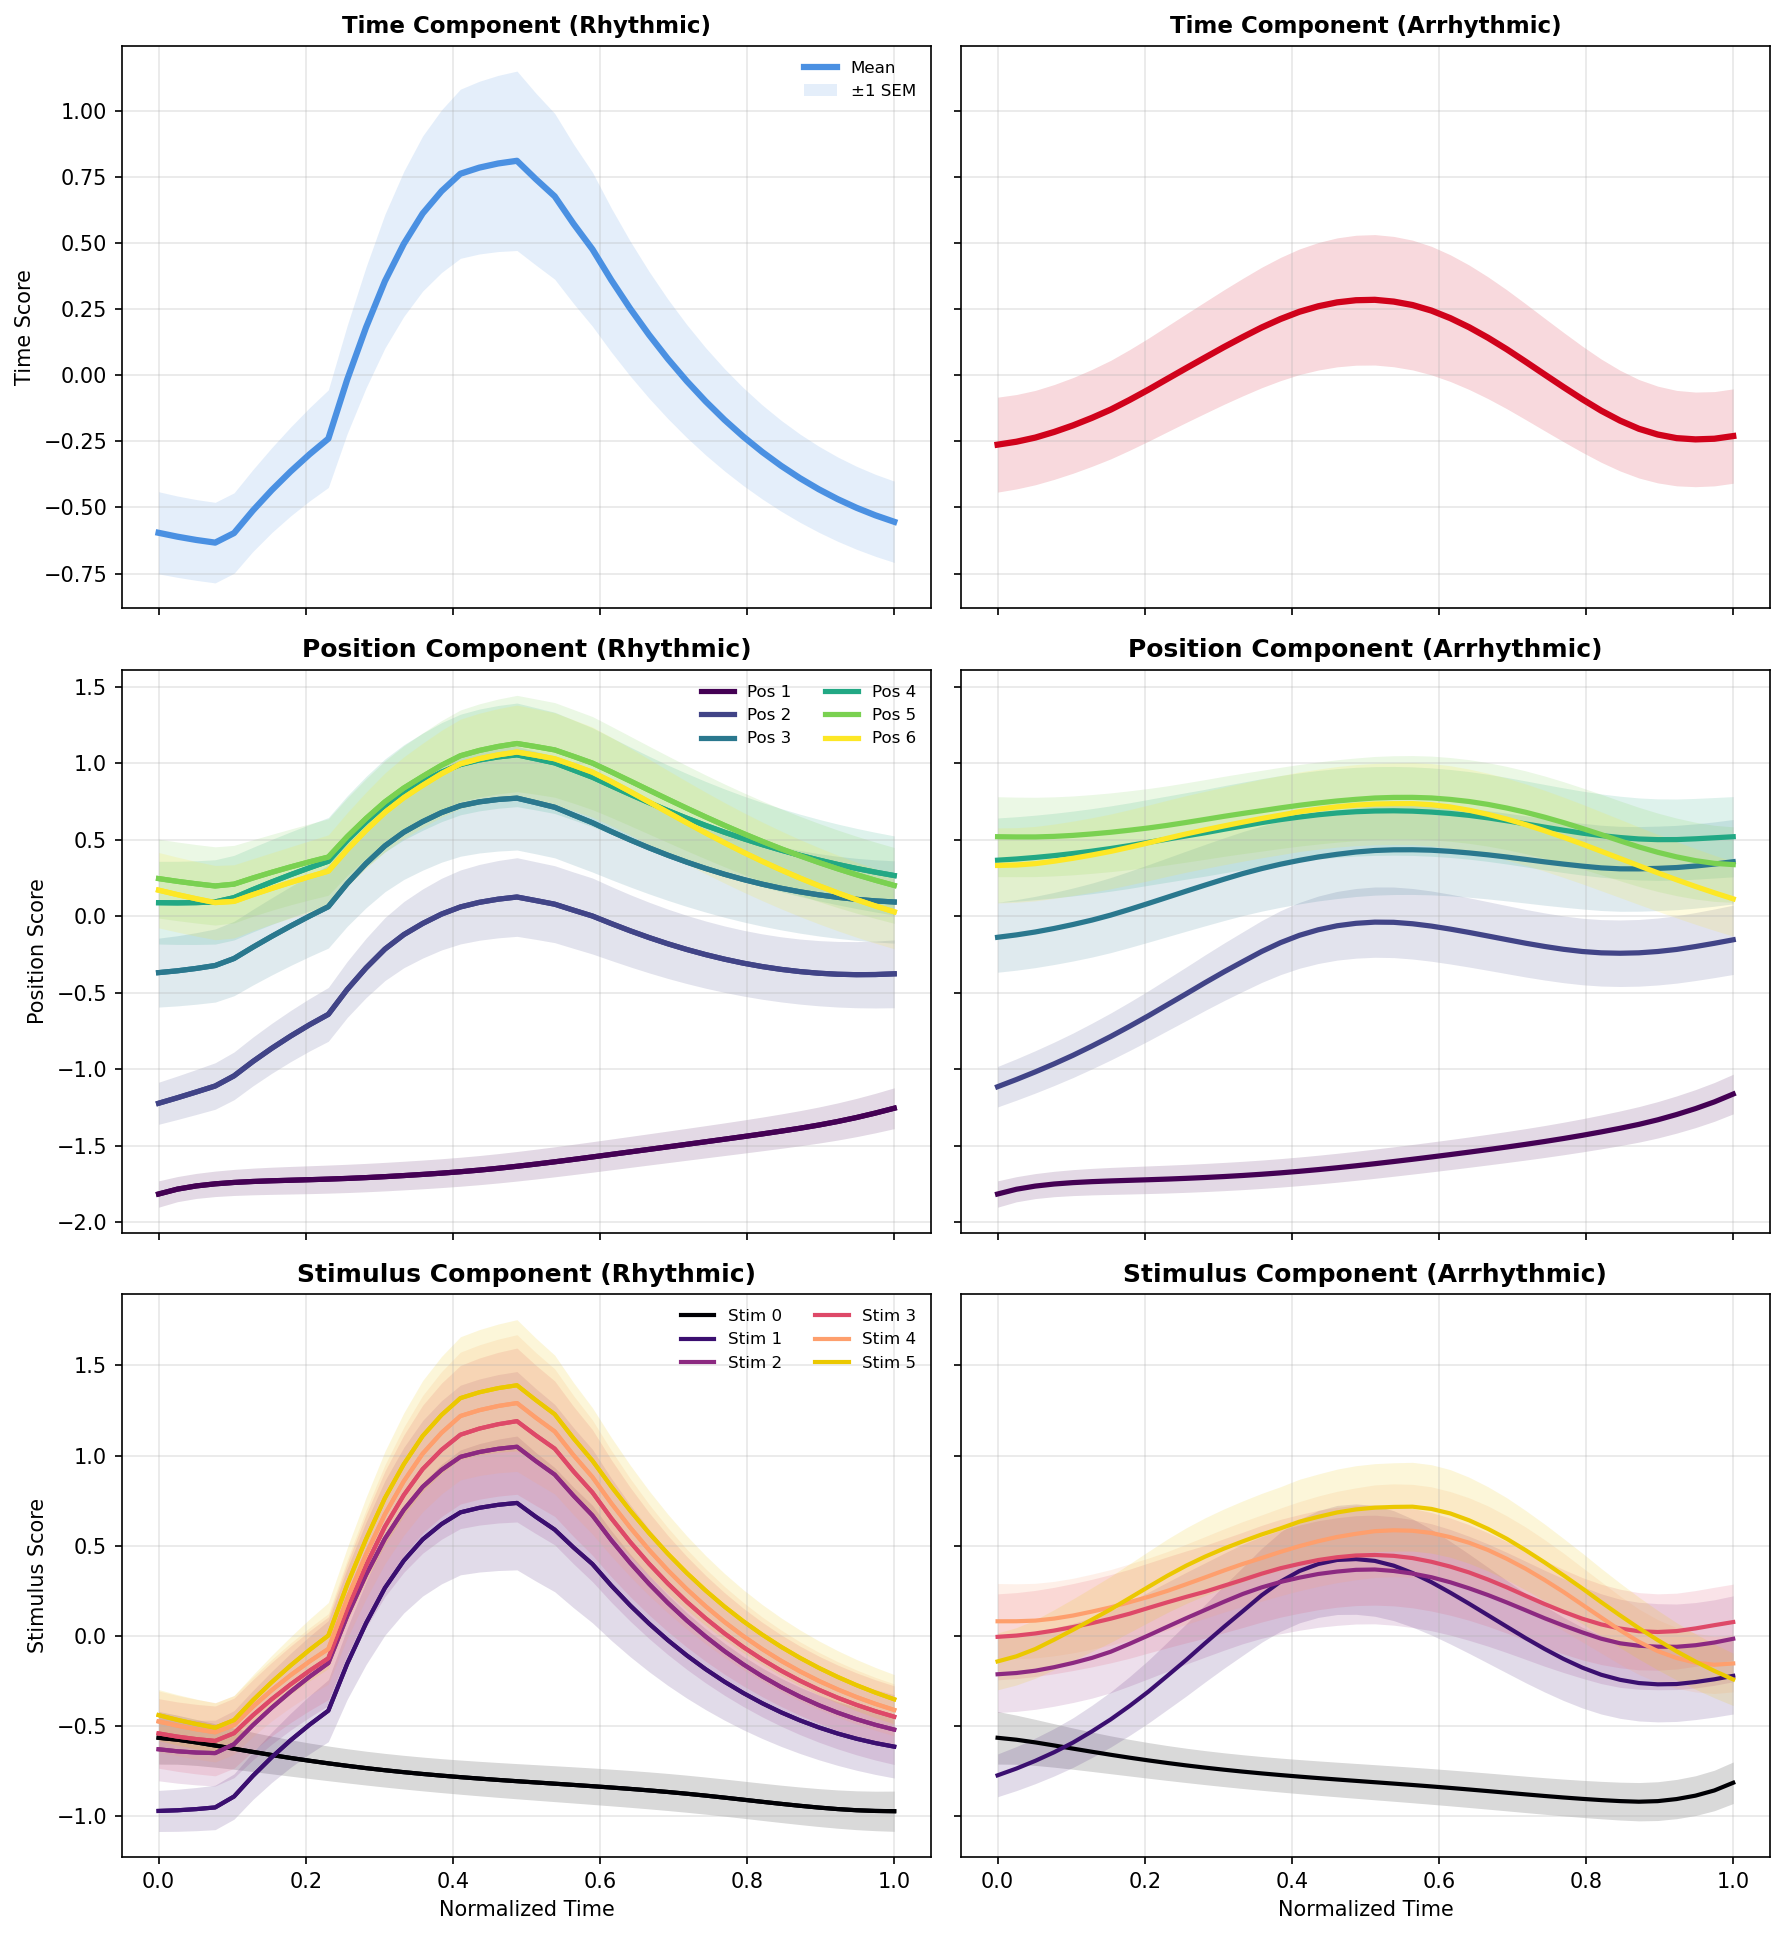

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from scipy.interpolate import interp1d
import os
import json
import matplotlib.cm as cm

# ==========================================
# 1. Global Configuration
# ==========================================
ROOT_PATH = './'

BASE_DIRS = [
    '100-400','120-400','140-400','100-450','120-450','140-450',
    '120-300','120-350','120-500','140-350','140-500'
]
LOCAL_LEN = 40
REGULARIZATION = 1e-6   
AVG_IOI = None

def reduced_rank_regression_pca(X, X_phi, n_components=5):
    N = X.shape[0]
    Cxx = X @ X.T
    Cxy = X_phi @ X.T
    reg = np.eye(N) * REGULARIZATION * np.trace(Cxx)
    try:
        D = Cxy @ np.linalg.inv(Cxx + reg)
    except:
        D = Cxy @ np.linalg.pinv(Cxx)
    X_hat = D @ X 
    pca = PCA(n_components=n_components)
    pca.fit(X_hat.T) 
    return pca

def build_data_and_train():
    print("Step 1: Building training matrix (reading all slices)...")
    
    acc_time_rhy, acc_time_arr = [], []
    acc_pos = [[] for _ in range(6)]
    acc_stim = [[] for _ in range(6)] 
    
    plot_stim_rhy = [[] for _ in range(6)]
    plot_stim_arr = [[] for _ in range(6)]

    X_list, meta_list = [], []
    
    for target_dir in BASE_DIRS:
        full_path = os.path.join(ROOT_PATH, target_dir)
        if not os.path.exists(full_path): continue
        
        meta_path = os.path.join(full_path, 'metadata_seed42_n400.json')
        if not os.path.exists(meta_path): continue
        with open(meta_path, 'r') as f: meta = json.load(f)
        
        onsets_rhy = np.array(meta['rhy_ch0_sample_onsets'])
        onsets_arr = np.array(meta['arrhy_ch0_sample_onsets'])
        
        seqs_rhy = np.array(meta['sample_seqs'])
        seqs_arr = seqs_rhy

        files = {
            'Rhy': ['activity_rhy_ch0_seed42_trials400.npz', 'activity_rhy_ch3_seed42_trials400.npz'],
            'Arr': ['activity_arrhy_ch0_seed42_trials400.npz', 'activity_arrhy_ch3_seed42_trials400.npz']
        }

        def process_files(file_list, onsets, seqs, cond_idx):
            for fname in file_list:
                p = os.path.join(full_path, fname)
                if not os.path.exists(p): continue
                d = np.load(p)
                k = 'hidden'
                data = d[k].transpose(1,0,2) # [Trials, Time, Neurons]
                
                for i in range(len(data)):
                    # Calculate AVG_IOI for global usage
                    avg_ioi = (onsets[i, 5] - onsets[i, 0]) / 5
                    global AVG_IOI
                    AVG_IOI = avg_ioi
                    
                    for p_idx in range(6):
                        t0 = int(onsets[i, p_idx])
                        if p_idx < 5: t1 = int(onsets[i, p_idx+1])
                        else: t1 = int(t0 + avg_ioi)
                        
                        if t1 > data.shape[1]: t1 = data.shape[1]
                        if t1 <= t0: continue
                        
                        seg = data[i, t0:t1, :]
                        if len(seg) <= 1: continue
                        
                        f = interp1d(np.linspace(0,1,len(seg)), seg, axis=0)
                        seg_new = f(np.linspace(0,1,LOCAL_LEN))
                        
                        stim_id = int(seqs[i][p_idx])
                        
                        if cond_idx == 0: acc_time_rhy.append(seg_new)
                        else: acc_time_arr.append(seg_new)
                        acc_pos[p_idx].append(seg_new)
                        if 0 <= stim_id < 6: acc_stim[stim_id].append(seg_new)
                        
                        X_list.append(seg_new.T)
                        meta_list.append({'cond': cond_idx, 'pos': p_idx, 'stim': stim_id})

                        if 0 <= stim_id < 6:
                            if cond_idx == 0: plot_stim_rhy[stim_id].append(seg_new)
                            else: plot_stim_arr[stim_id].append(seg_new)

        process_files(files['Rhy'], onsets_rhy, seqs_rhy, 0)
        process_files(files['Arr'], onsets_arr, seqs_arr, 1)

    if not X_list: return None

    print("Calculating mean trajectories...")
    mean_time = np.stack([np.mean(acc_time_rhy, axis=0), np.mean(acc_time_arr, axis=0)])
    mean_pos_traj = np.array([np.mean(acc_pos[p], axis=0) for p in range(6)])
    mean_stim_traj = np.array([np.mean(acc_stim[s], axis=0) if len(acc_stim[s])>0 else np.zeros((LOCAL_LEN, mean_time.shape[2])) for s in range(6)])
    
    mean_plot_stim_rhy = np.array([np.mean(plot_stim_rhy[s], axis=0) if len(plot_stim_rhy[s])>0 else np.zeros((LOCAL_LEN, mean_time.shape[2])) for s in range(6)])
    mean_plot_stim_arr = np.array([np.mean(plot_stim_arr[s], axis=0) if len(plot_stim_arr[s])>0 else np.zeros((LOCAL_LEN, mean_time.shape[2])) for s in range(6)])

    print("Building regression matrix...")
    X = np.concatenate(X_list, axis=1)
    X_mean = np.mean(X, axis=1, keepdims=True)
    X_centered = X - X_mean
    
    X_phi_time = np.zeros_like(X)
    X_phi_pos = np.zeros_like(X)
    X_phi_stim = np.zeros_like(X)
    
    current_col = 0
    for meta in meta_list:
        X_phi_time[:, current_col:current_col+LOCAL_LEN] = mean_time[meta['cond']].T
        X_phi_pos[:, current_col:current_col+LOCAL_LEN] = mean_pos_traj[meta['pos']].T
        if 0 <= meta['stim'] < 6:
            X_phi_stim[:, current_col:current_col+LOCAL_LEN] = mean_stim_traj[meta['stim']].T
        current_col += LOCAL_LEN
        
    X_phi_time -= X_mean
    X_phi_pos -= X_mean
    X_phi_stim -= X_mean
    
    return {
        'X': X_centered, 
        'X_time': X_phi_time, 'X_pos': X_phi_pos, 'X_stim': X_phi_stim,
        'global_mean': X_mean,
        'mean_plot_stim_rhy': mean_plot_stim_rhy,
        'mean_plot_stim_arr': mean_plot_stim_arr 
    }


def train_dpca(data_dict):
    print("Step 2: Training dPCA model...")
    X = data_dict['X']
    total_var_data = np.sum(X**2)
    
    candidates = []
    marginals = {'Time': data_dict['X_time'], 'Position': data_dict['X_pos'], 'Stimulus': data_dict['X_stim']}

    explained_variances = {}
    
    for name, X_phi in marginals.items():

        total_var_marginal = np.sum(X_phi**2)

        pca = reduced_rank_regression_pca(X, X_phi, n_components=5)
        W = pca.components_

        print(f"\n[{name} Component Analysis]")
        print(f"  > Subspace Total Energy relative to Global: {total_var_marginal/total_var_data:.2%}")
        
        for i in range(len(W)):
            w = W[i]
            w = w / np.linalg.norm(w)
            z = X.T @ w

            var_captured_global = np.sum(z**2)
            ratio_global = var_captured_global / total_var_data
            z_phi = X_phi.T @ w 
            var_captured_marginal = np.sum(z_phi**2)

            if total_var_marginal > 1e-9:
                ratio_marginal = var_captured_marginal / total_var_marginal
            else:
                ratio_marginal = 0.0

            print(f"  PC{i+1}: Global={ratio_global:6.2%} | Within {name} Subspace={ratio_marginal:6.2%}")

            candidates.append({'axis': W[i], 'source': name})


    final_components = []
    for cand in candidates:
        w = cand['axis']
        w = w / np.linalg.norm(w)
        z = X.T @ w
        total_var = np.var(z) * X.shape[1]
        
        var_marginals = {}
        for name, X_phi in marginals.items():
            z_phi = X_phi.T @ w
            var_marginals[name] = np.sum(z_phi**2)
        
        best_marginal = max(var_marginals, key=var_marginals.get)
        final_components.append({
            'axis': w, 
            'var_ratio': total_var/total_var_data, 
            'source': cand['source'],
            'assigned_label': best_marginal
        })
        
    final_components.sort(key=lambda x: x['var_ratio'], reverse=True)
    return final_components

def get_grand_average_data(global_mean):
    print(f"Step 3 (Grand Avg): Reading and warping ALL {len(BASE_DIRS)} datasets...")
    
    all_datasets_rhy = []
    all_datasets_arr = []
    
    for dir_idx, target_dir in enumerate(BASE_DIRS):
        full_path = os.path.join(ROOT_PATH, target_dir)
        meta_path = os.path.join(full_path, 'metadata_seed42_n400.json')
        if not os.path.exists(meta_path): continue
        
        with open(meta_path, 'r') as f: meta = json.load(f)
        onsets_rhy = np.array(meta['rhy_ch0_sample_onsets'])
        onsets_arr = np.array(meta['arrhy_ch0_sample_onsets'])
        
        files = {
            'Rhy': ['activity_rhy_ch0_seed42_trials400.npz', 'activity_rhy_ch3_seed42_trials400.npz'],
            'Arr': ['activity_arrhy_ch0_seed42_trials400.npz', 'activity_arrhy_ch3_seed42_trials400.npz']
        }
        
        warped_rhy = [[] for _ in range(6)]
        warped_arr = [[] for _ in range(6)]
        
        def process_and_warp_local(file_list, onsets, container):
            for fname in file_list:
                p = os.path.join(full_path, fname)
                if not os.path.exists(p): continue
                d = np.load(p)
                k = 'hidden'
                data = d[k].transpose(1,0,2)
                for i in range(len(data)):
                    curr_ioi = (onsets[i, 5] - onsets[i, 0]) / 5
                    for s_id in range(6):
                        t0 = int(onsets[i, s_id])
                        if s_id < 5: t1 = int(onsets[i, s_id+1])
                        else: t1 = int(t0 + curr_ioi)
                        if t1 > data.shape[1]: t1 = data.shape[1]
                        if t1 <= t0 + 1: continue
                        
                        raw_seg = data[i, t0:t1, :]
                        f = interp1d(np.linspace(0,1,len(raw_seg)), raw_seg, axis=0)
                        warped_seg = f(np.linspace(0,1,LOCAL_LEN))
                        container[s_id].append(warped_seg)

        process_and_warp_local(files['Rhy'], onsets_rhy, warped_rhy)
        process_and_warp_local(files['Arr'], onsets_arr, warped_arr)

        ds_mean_rhy = np.array([np.mean(warped_rhy[s], axis=0) for s in range(6)])
        ds_mean_arr = np.array([np.mean(warped_arr[s], axis=0) for s in range(6)])
        
        ds_mean_rhy -= global_mean.T
        ds_mean_arr -= global_mean.T
        
        all_datasets_rhy.append(ds_mean_rhy)
        all_datasets_arr.append(ds_mean_arr)
        print(f"  - Dataset {target_dir} processed.")

    stack_rhy = np.stack(all_datasets_rhy, axis=0)
    stack_arr = np.stack(all_datasets_arr, axis=0)
    
    grand_mean_rhy = np.mean(stack_rhy, axis=0) # [6, LOCAL_LEN, N]
    grand_mean_arr = np.mean(stack_arr, axis=0)

    grand_sem_rhy = np.std(stack_rhy, axis=0) / np.sqrt(len(BASE_DIRS))
    grand_sem_arr = np.std(stack_arr, axis=0) / np.sqrt(len(BASE_DIRS))

    cont_rhy_aligned = np.concatenate(grand_mean_rhy, axis=0)
    cont_arr_aligned = np.concatenate(grand_mean_arr, axis=0)
    
    return {
        'segs_rhy': grand_mean_rhy,
        'segs_arr': grand_mean_arr,
        'cont_rhy': cont_rhy_aligned,
        'cont_arr': cont_arr_aligned,
        'sem_rhy': grand_sem_rhy,
        'sem_arr': grand_sem_arr
    }


# ==========================================
# 7. Final Plotting: Grand Mean + Standard Error Shading
# ==========================================
def plot_final_clean_comparison(data_dict, final_components, mean_rhy_cont, mean_arr_cont, sem_rhy_cont=None, sem_arr_cont=None):
    print("Step 5: Plotting final clean comparison (with Standard Error Shading)...")
    
    # 1. Extract Components
    top_time = next((c for c in final_components if c['source'] == 'Time'), None)
    top_pos  = next((c for c in final_components if c['source'] == 'Position'), None)
    top_stim = next((c for c in final_components if c['source'] == 'Stimulus'), None)
    
    # --- Helper: Project Error from High-Dim to Low-Dim ---
    def project_error(sem_matrix, w):
        """
        Calculates the projected standard error.
        Formula: sqrt( (SE^2) @ (w^2) ) assuming independent noise.
        """
        if sem_matrix is None or w is None: return None
        # Square the SE, Square the weights, Dot product, then Sqrt
        return np.sqrt((sem_matrix**2) @ (w**2))

    # 3. Prepare Plotting Slices
    chunk_size = LOCAL_LEN
    t_norm = np.linspace(0, 1, chunk_size)
    
    fig, axes = plt.subplots(3, 2, figsize=(12, 13), dpi=150, sharey='row', sharex=True)
    
    # --- Helper: Plot Function (With Shading) ---
    def plot_time_clean(ax, data, sem_data, w, color, title):
        if w is None: return
        
        # Project Mean
        proj_mean = data @ w 
        # Project Error (if available)
        proj_err = project_error(sem_data, w)
        
        segments_mean = []
        segments_err = []
        
        for i in range(6):
            start, end = i*chunk_size, (i+1)*chunk_size
            segments_mean.append(proj_mean[start:end])
            if proj_err is not None:
                segments_err.append(proj_err[start:end])
        
        seg_matrix_mean = np.array(segments_mean)
        
        # 2. Grand Mean Line
        grand_curve = np.mean(seg_matrix_mean, axis=0)
        ax.plot(t_norm, grand_curve, color=color, alpha=1.0, lw=3, label='Mean')
        
        # 3. *** Error Shading ***
        if proj_err is not None:
            seg_matrix_err = np.array(segments_err)
            # Average the error across the 6 segments to get the error for the "Grand Mean"
            grand_err = np.mean(seg_matrix_err, axis=0) 
            
            ax.fill_between(t_norm, 
                            grand_curve - grand_err, 
                            grand_curve + grand_err, 
                            color=color, alpha=0.15, lw=0, label='±1 SEM')
        
        ax.set_title(title, fontweight='bold', fontsize=11)
        ax.grid(alpha=0.3)

    # --- Row 1: Time (With Shading) ---
    if top_time:
        plot_time_clean(axes[0,0], mean_rhy_cont, sem_rhy_cont, top_time['axis'], '#4A90E2' ,
                        "Time Component (Rhythmic)")
        plot_time_clean(axes[0,1], mean_arr_cont, sem_arr_cont, top_time['axis'], '#D0021B' ,
                        "Time Component (Arrhythmic)")
        axes[0,0].legend(loc='upper right', fontsize=8, frameon=False)

    # --- Row 2: Position (With Shading) ---
    colors = ['#440154', '#414487', '#2a788e', '#22a884', '#7ad151', '#fde725']
    if top_pos:
        proj_r = mean_rhy_cont @ top_pos['axis']
        proj_a = mean_arr_cont @ top_pos['axis']
        
        # Calculate Projected Error
        err_r = project_error(sem_rhy_cont, top_pos['axis'])
        err_a = project_error(sem_arr_cont, top_pos['axis'])
        
        for i in range(6):
            s, e = i*chunk_size, (i+1)*chunk_size
            
            # Rhythmic
            axes[1,0].plot(t_norm, proj_r[s:e], color=colors[i], lw=2.5)
            if err_r is not None:
                axes[1,0].fill_between(t_norm, 
                                       proj_r[s:e] - err_r[s:e], 
                                       proj_r[s:e] + err_r[s:e], 
                                       color=colors[i], alpha=0.15, lw=0)
            
            axes[1,0].plot(t_norm, proj_r[s:e], color=colors[i], lw=2.5, label=f'Pos {i+1}')

            # Arrhythmic
            axes[1,1].plot(t_norm, proj_a[s:e], color=colors[i], lw=2.5)
            if err_a is not None:
                axes[1,1].fill_between(t_norm, 
                                       proj_a[s:e] - err_a[s:e], 
                                       proj_a[s:e] + err_a[s:e], 
                                       color=colors[i], alpha=0.15, lw=0)
                
        axes[1,0].legend(loc='upper right', fontsize=8, ncol=2, frameon=False)
        axes[1,0].set_title("Position Component (Rhythmic)", fontweight='bold')
        axes[1,1].set_title("Position Component (Arrhythmic)", fontweight='bold')
        axes[1,0].grid(alpha=0.3)
        axes[1,1].grid(alpha=0.3)

    # --- Row 3: Stimulus (With Shading) ---
    colors_stim = ['#000004', '#3b0f70', '#8c2981', '#de4968', '#fe9f6d', "#ebc800"]
    if top_stim:
        for s in range(6):
            # Mean Data
            tr_r = data_dict['mean_plot_stim_rhy'][s] @ top_stim['axis']
            tr_a = data_dict['mean_plot_stim_arr'][s] @ top_stim['axis']
            
            # Extract SEM Data (Retrieve from dictionary)
            sem_r_raw = data_dict.get('sem_plot_stim_rhy', [None]*6)[s]
            sem_a_raw = data_dict.get('sem_plot_stim_arr', [None]*6)[s]
            
            # Calculate Projected Error
            e_r = project_error(sem_r_raw, top_stim['axis'])
            e_a = project_error(sem_a_raw, top_stim['axis'])
            
            # Rhythmic
            axes[2,0].plot(t_norm, tr_r, color=colors_stim[s], lw=2)
            if e_r is not None:
                axes[2,0].fill_between(t_norm, tr_r - e_r, tr_r + e_r, color=colors_stim[s], alpha=0.15, lw=0)
            axes[2,0].plot(t_norm, tr_r, color=colors_stim[s], lw=2, label=f'Stim {s}')

            # Arrhythmic
            axes[2,1].plot(t_norm, tr_a, color=colors_stim[s], lw=2)
            if e_a is not None:
                axes[2,1].fill_between(t_norm, tr_a - e_a, tr_a + e_a, color=colors_stim[s], alpha=0.15, lw=0)

        axes[2,0].legend(loc='upper right', fontsize=8, ncol=2, frameon=False)  
        axes[2,0].set_title("Stimulus Component (Rhythmic)", fontweight='bold')
        axes[2,1].set_title("Stimulus Component (Arrhythmic)", fontweight='bold')
        axes[2,0].grid(alpha=0.3)
        axes[2,1].grid(alpha=0.3)

    axes[0,0].set_ylabel("Time Score")
    axes[1,0].set_ylabel("Position Score")
    axes[2,0].set_ylabel("Stimulus Score")
    axes[2,0].set_xlabel("Normalized Time")
    axes[2,1].set_xlabel("Normalized Time")

    plt.tight_layout()
    plt.savefig('final_clean_comparison_with_sem.svg', format='svg', transparent=True)
    plt.show()


# ==========================================
# Main Execution
# ==========================================
if __name__ == "__main__":
    data_dict = build_data_and_train()
    
    if data_dict:
        final_comps = train_dpca(data_dict)

        target_dir_index = 2
        warped_data = get_grand_average_data(data_dict['global_mean'])
        
        if warped_data:
            data_dict['mean_plot_stim_rhy'] = warped_data['segs_rhy']
            data_dict['mean_plot_stim_arr'] = warped_data['segs_arr']
            
            data_dict['sem_plot_stim_rhy'] = warped_data['sem_rhy'] 
            data_dict['sem_plot_stim_arr'] = warped_data['sem_arr']

            sem_cont_rhy = warped_data['sem_rhy'].reshape(-1, warped_data['sem_rhy'].shape[-1]) 
            sem_cont_arr = warped_data['sem_arr'].reshape(-1, warped_data['sem_arr'].shape[-1])
            
            plot_final_clean_comparison(
                data_dict,
                final_comps,
                warped_data['cont_rhy'], 
                warped_data['cont_arr'],
                sem_rhy_cont=sem_cont_rhy,
                sem_arr_cont=sem_cont_arr
            )
